# ImageNet-100 — ResNet-50 from Scratch

A custom implementation of ResNet-50 adapted for ImageNet-100's 32×32 input.
Uses `Bottleneck` blocks (1×1 → 3×3 → 1×1 convolution pattern, expansion=4)
with `_make_layer` to stack [3, 4, 6, 3] blocks per stage (4 stages),
matching the original ResNet-50 architecture but with a CIFAR-friendly
3×3 stem instead of the ImageNet 7×7 stem (which would shrink 32×32
images too aggressively).


## Imports

In [1]:
import sys
sys.path.append('../..')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

from utils.dataset import get_imagenet100_dataloaders
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch


## Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')


Using device: cuda


## Data Pipeline

In [3]:
batch_size = 192

trainloader, valloader, testloader = get_imagenet100_dataloaders(
    batch_size=batch_size, num_workers=4, img_size=224,
)

print(f'Train batches: {len(trainloader)} | Val batches: {len(valloader)} | Test batches: {len(testloader)}')


C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Dataset] Loading 'ilee0022/ImageNet100' (local cache: C:\Users\asmit\PycharmProjects\CIFAR_10\data\huggingface)...
Train batches: 610 | Val batches: 27 | Test batches: 68


## Visualize Sample Batch

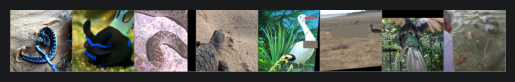

14    11    85    93    97    27    22    6    


In [4]:
show_sample_batch(trainloader, [str(i) for i in range(100)])


## Model Definition

### Bottleneck Block
The standard ResNet bottleneck block: 1×1 conv (reduce) → 3×3 conv →
1×1 conv (expand, ×4) with BatchNorm and a shortcut connection
(identity or 1×1 projection). The `expansion = 4` factor means the
output channels are 4× the intermediate ("planes") width.

### ResNet50
4 stages with [3, 4, 6, 3] `Bottleneck` blocks — totaling ~23.5M parameters.
Uses a CIFAR-friendly 3×3 stem (no 7×7 conv or initial max-pooling).


## Initialize Model & Print Summary

In [5]:
import torchvision.models as models
# Initialize standard ResNet-50 from scratch (no weights)
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 100)  # 100 classes for ImageNet-100
model.to(device)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')


Model parameters: 23,712,932


## Training Configuration

In [6]:
criterion = nn.CrossEntropyLoss()
epochs = 90
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,
    steps_per_epoch=len(trainloader),
    epochs=epochs,
    pct_start=0.10,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=1e4,
)

# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

scaler = torch.amp.GradScaler('cuda')
NAME = 'resnet50_100_imagenet'
checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path=f'../../checkpoint/{NAME}_latest.pth',
    best_model_path=f'../../checkpoint/{NAME}_best.pth',
    mode='max',
    verbose=True,
)


## Training Loop

In [7]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint,
    step_scheduler_per_batch=True,
    log=True, resume_from_checkpoint=True
)


[RunLogger] ▶  Run 'resnet_20260609_091619' started — saving to 'C:\Users\asmit\PycharmProjects\CIFAR_10\logs\runs\resnet_20260609_091619.json'
[RunLogger] Logging to 'C:\Users\asmit\PycharmProjects\CIFAR_10\logs\runs/'  —  run: 'resnet_20260609_091619'
[ModelCheckpoint] Resumed from epoch 49, starting at epoch 50
[ModelCheckpoint] New best (max): 65.6600 — saved to ..\checkpoint\resnet50_100_imagenet_best.pth
[RunLogger] Epoch  50 | train_loss=1.3413  val_loss=1.2686  val_metric=65.66 dB  lr=4.91e-02  ⏱ 137.5s  ★ NEW BEST
Epoch [50/90]  Train Loss: 1.3413  Val Loss: 1.2686  Val Acc: 65.66%  LR: 0.049056  Time: 137.52s
[RunLogger] Epoch  51 | train_loss=1.3311  val_loss=1.3229  val_metric=64.92 dB  lr=4.71e-02  ⏱ 125.1s
Epoch [51/90]  Train Loss: 1.3311  Val Loss: 1.3229  Val Acc: 64.92%  LR: 0.047122  Time: 125.08s
[ModelCheckpoint] New best (max): 67.7200 — saved to ..\checkpoint\resnet50_100_imagenet_best.pth
[RunLogger] Epoch  52 | train_loss=1.3211  val_loss=1.1683  val_metric=67.

## Restore Best Weights & Test Evaluation

In [8]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, [str(i) for i in range(100)], device)
print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
for name, acc in per_class.items():
    print(f'  {name:5s}: {acc:.1f}%')


[ModelCheckpoint] Restored best weights from ..\checkpoint\resnet50_100_imagenet_best.pth (score=85.5000)

Overall Test Accuracy: 88.34%

  0    : 96.8%
  1    : 83.8%
  2    : 98.4%
  3    : 95.8%
  4    : 100.0%
  5    : 94.6%
  6    : 81.3%
  7    : 93.8%
  8    : 88.2%
  9    : 84.3%
  10   : 96.6%
  11   : 90.8%
  12   : 67.5%
  13   : 87.6%
  14   : 62.0%
  15   : 51.2%
  16   : 93.0%
  17   : 87.2%
  18   : 85.4%
  19   : 87.0%
  20   : 97.6%
  21   : 94.4%
  22   : 97.0%
  23   : 78.0%
  24   : 83.6%
  25   : 98.7%
  26   : 92.6%
  27   : 92.6%
  28   : 94.0%
  29   : 96.6%
  30   : 92.9%
  31   : 98.6%
  32   : 94.9%
  33   : 74.4%
  34   : 87.5%
  35   : 88.7%
  36   : 86.1%
  37   : 97.2%
  38   : 79.4%
  39   : 95.5%
  40   : 89.5%
  41   : 96.3%
  42   : 94.7%
  43   : 86.1%
  44   : 91.0%
  45   : 94.2%
  46   : 86.8%
  47   : 92.9%
  48   : 73.9%
  49   : 78.0%
  50   : 45.7%
  51   : 97.2%
  52   : 87.4%
  53   : 86.8%
  54   : 73.9%
  55   : 100.0%
  56   : 78.2%
  57 

## Training Curves

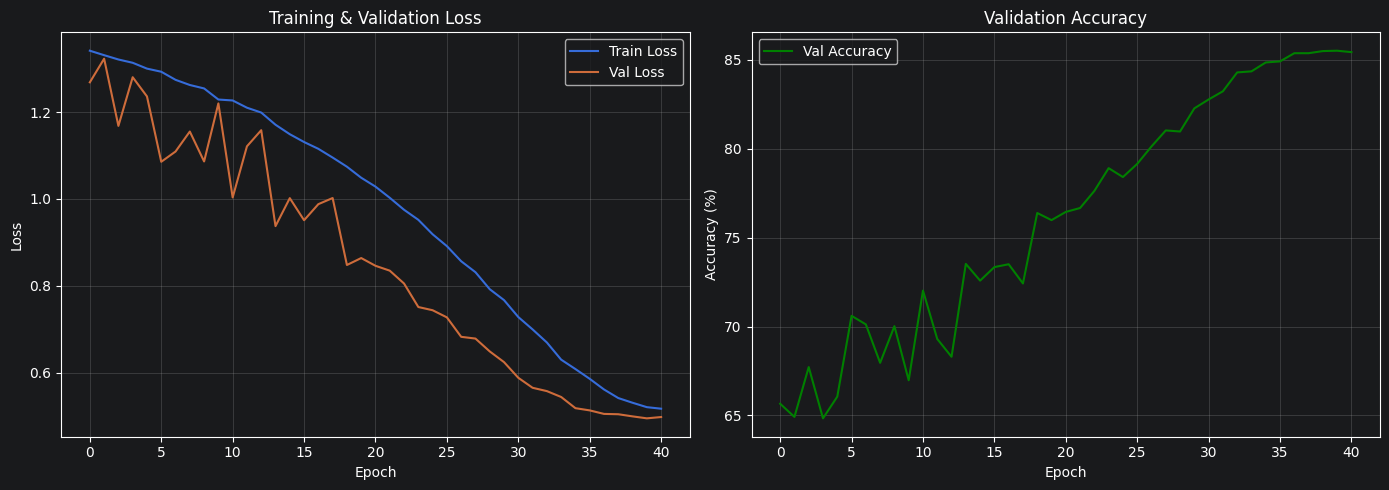

In [9]:
plot_training_curves(train_losses, val_losses, val_accuracies)
